# 05 — Baseline Model: Train / Validate / Predict

Train a gradient-boosting classifier on the physics-informed features, measure performance on a held-out **validation** split (Brier score, the competition metric), then refit on all training data and predict on the test set.

**Key choice — grouped split.** Each aircraft contributes *both* its y=0 and y=1 row. A random row split would put the same aircraft on both sides and leak. So we split **by aircraft** (`GroupShuffleSplit` on `aircraft_id`): a plane is entirely in train OR entirely in validation.

Inputs: `output/train_features_*.csv` and `output/test_features_*.csv` from [`04_feature_engineering.ipynb`](04_feature_engineering.ipynb).

In [1]:
import pandas as pd
import numpy as np
from pathlib import Path
from sklearn.model_selection import GroupShuffleSplit
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.metrics import brier_score_loss, roc_auc_score
from sklearn.inspection import permutation_importance
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', 80)
RANDOM_STATE = 42
OUT = Path('..') / 'output'

## 1. Load the feature matrices (latest)

In [2]:
train_path = sorted(OUT.glob('train_features_*.csv'))[-1]
test_path  = sorted(OUT.glob('test_features_*.csv'))[-1]
print('train:', train_path.name)
print('test :', test_path.name)

train = pd.read_csv(train_path)
test  = pd.read_csv(test_path)
print(train.shape, test.shape)

train: train_features_20260611_144825.csv
test : test_features_20260611_144825.csv


(1516, 97) (14303, 88)


## 2. Choose features & target
Use every numeric feature (raw environmental columns **and** the engineered physics features), minus identifiers, the target, and **data-availability flags**. Those flags (`feat_gap_months`, `exact_month`, `env_available`) track *recency of data*, which correlates with the label (y=1 rows are recent) — including them would leak.

In [3]:
BLOCK = {'y', 'aircraft_id', 'year_month', 'feat_year_month', 'ref_month',
         'ref_ts', 'feat_ts', 'month_start_date',
         'feat_gap_months', 'exact_month', 'env_available', 'flag_prior_corrosion'}

FEATURES = [c for c in train.columns
            if c not in BLOCK and pd.api.types.is_numeric_dtype(train[c])]
# keep only features that also exist in the test table (identical pipeline -> should be all)
missing_in_test = [c for c in FEATURES if c not in test.columns]
FEATURES = [c for c in FEATURES if c in test.columns]
print(f'using {len(FEATURES)} features; dropped (absent in test): {missing_in_test}')

X = train[FEATURES]
y = train['y'].astype(int)
groups = train['aircraft_id']
print('rows with at least one NaN feature (kept; HGB handles NaN):', int(X.isna().any(axis=1).sum()))

using 85 features; dropped (absent in test): []
rows with at least one NaN feature (kept; HGB handles NaN): 149


## 3. Aircraft-grouped train / validation split
80% of aircraft to train, 20% to validation — no aircraft spans both.

In [4]:
gss = GroupShuffleSplit(n_splits=1, test_size=0.20, random_state=RANDOM_STATE)
tr_idx, va_idx = next(gss.split(X, y, groups))
X_tr, X_va = X.iloc[tr_idx], X.iloc[va_idx]
y_tr, y_va = y.iloc[tr_idx], y.iloc[va_idx]

print('train rows:', len(tr_idx), '| aircraft:', groups.iloc[tr_idx].nunique())
print('valid rows:', len(va_idx), '| aircraft:', groups.iloc[va_idx].nunique())
assert set(groups.iloc[tr_idx]) & set(groups.iloc[va_idx]) == set(), 'aircraft leak!'
print('label balance  train:', y_tr.value_counts().to_dict(), '| valid:', y_va.value_counts().to_dict())

train rows: 1212 | aircraft: 606
valid rows: 304 | aircraft: 152
label balance  train: {0: 606, 1: 606} | valid: {0: 152, 1: 152}


## 4. Train the model
`HistGradientBoostingClassifier` — fast, handles NaNs natively, good on small tabular data.

In [5]:
model = HistGradientBoostingClassifier(
    max_iter=300,
    learning_rate=0.05,
    max_leaf_nodes=31,
    l2_regularization=1.0,
    random_state=RANDOM_STATE,
)
model.fit(X_tr, y_tr)
print('fitted on', X_tr.shape[0], 'rows,', X_tr.shape[1], 'features')

fitted on 1212 rows, 85 features


## 5. Validation score (Brier — lower is better)
Compare against two baselines: a constant 0.5 (Brier = 0.25) and the train base rate.

In [6]:
p_va = model.predict_proba(X_va)[:, 1]

brier      = brier_score_loss(y_va, p_va)
brier_half = brier_score_loss(y_va, np.full(len(y_va), 0.5))
base_rate  = y_tr.mean()
brier_base = brier_score_loss(y_va, np.full(len(y_va), base_rate))
auc        = roc_auc_score(y_va, p_va)

print(f'Validation Brier (model)      : {brier:.4f}')
print(f'Validation Brier (constant .5): {brier_half:.4f}   <- the baseline to beat')
print(f'Validation Brier (base rate)  : {brier_base:.4f}')
print(f'Validation ROC AUC            : {auc:.4f}')

Validation Brier (model)      : 0.1514
Validation Brier (constant .5): 0.2500   <- the baseline to beat
Validation Brier (base rate)  : 0.2500
Validation ROC AUC            : 0.8703


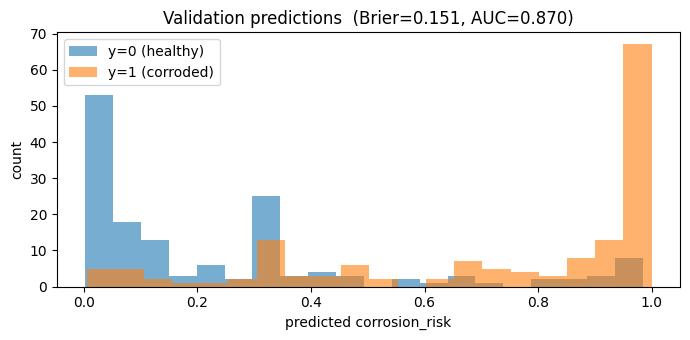

In [7]:
# Predicted-probability distribution by true class (well-separated = good)
fig, ax = plt.subplots(figsize=(7, 3.5))
ax.hist(p_va[y_va == 0], bins=20, alpha=0.6, label='y=0 (healthy)')
ax.hist(p_va[y_va == 1], bins=20, alpha=0.6, label='y=1 (corroded)')
ax.set_xlabel('predicted corrosion_risk'); ax.set_ylabel('count'); ax.legend()
ax.set_title(f'Validation predictions  (Brier={brier:.3f}, AUC={auc:.3f})')
plt.tight_layout(); plt.show()

## 6. Which features drive the model? (permutation importance)
Computed on the validation split. Expect the **cumulative dose** and **age** features near the top — the physics story, confirmed by the model.

In [8]:
perm = permutation_importance(model, X_va, y_va, scoring='neg_brier_score',
                              n_repeats=10, random_state=RANDOM_STATE)
imp = (pd.Series(perm.importances_mean, index=FEATURES)
       .sort_values(ascending=False))
imp.head(15)

age_months                            0.114503
total_parking_minutes                 0.057516
sulphur_dioxide_mass_mixing_ratio     0.004970
parking_hours_cum                     0.003390
wet_parking_cum                       0.003003
metar_wind_speed_kn                   0.002723
acid_dose_roll24m                     0.002525
h2o2                                  0.002460
salt_wet_dose_cum                     0.002330
tow_gate                              0.002069
nitrogen_dioxide_mass_mixing_ratio    0.002050
dust_aerosol_09_20_mixing_ratio       0.002006
specific_humidity                     0.001957
sea_salt_aerosol_5_20_mixing_ratio    0.001918
hno3                                  0.001847
dtype: float64

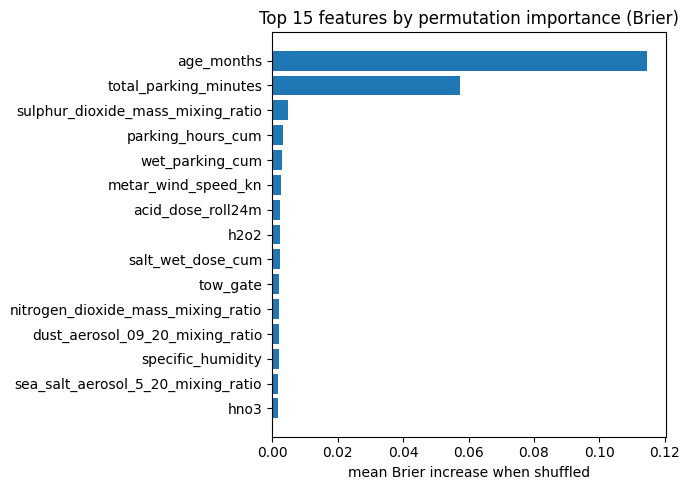

In [9]:
top = imp.head(15)[::-1]
fig, ax = plt.subplots(figsize=(7, 5))
ax.barh(top.index, top.values)
ax.set_title('Top 15 features by permutation importance (Brier)')
ax.set_xlabel('mean Brier increase when shuffled')
plt.tight_layout(); plt.show()

## 7. Refit on ALL training data, then predict the test set
Standard practice: once validation has told us the model is sound, retrain on every labeled row before predicting test (more data = better final model).

In [10]:
final_model = HistGradientBoostingClassifier(
    max_iter=300, learning_rate=0.05, max_leaf_nodes=31,
    l2_regularization=1.0, random_state=RANDOM_STATE,
)
final_model.fit(X, y)

X_test = test[FEATURES]
test_proba = final_model.predict_proba(X_test)[:, 1]
print('predicted', len(test_proba), 'test rows | proba range',
      round(float(test_proba.min()), 3), '->', round(float(test_proba.max()), 3))

predicted 14303 test rows | proba range 0.001 -> 0.999


## 8. Build the submission-format predictions
One probability per **(aircraft, month)** test row, with `id = aircraft_id_year_month`. This covers **every** test row; when `sample_submission.csv` is available, merge on `id` to keep exactly the scored rows.

In [11]:
submission = pd.DataFrame({
    'id': test['aircraft_id'].astype(str) + '_' + test['year_month'].astype(str),
    'corrosion_risk': test_proba.clip(0, 1),
})
print(submission.shape)
submission.head()

(14303, 2)


,id,corrosion_risk
0,022433_2020-11,0.079545
1,022433_2020-12,0.018450
2,022433_2021-01,0.043194
3,022433_2021-02,0.017282
4,022433_2021-03,0.032977


In [12]:
ts = pd.Timestamp.now().strftime('%Y%m%d_%H%M%S')
pred_path = OUT / f'test_predictions_{ts}.csv'
submission.to_csv(pred_path, index=False)
print('saved:', pred_path.name)

saved: test_predictions_20260611_145744.csv


## 9. Takeaway
- Validation Brier vs the 0.25 baseline tells us whether the features carry real signal.
- The grouped split means the score is an honest estimate of unseen-aircraft performance.
- Predictions for every test row are saved; filter to `sample_submission.csv` ids to submit.

**Next improvements:** k-fold grouped CV (not a single split) for a more stable score, probability **calibration** (isotonic/Platt — the Brier metric rewards it), and light hyper-parameter tuning. The `feat_gap_months` flag could also gate a fallback for the ~147 no-history rows.